# NHL Puck Management — Composite Score

This notebook combines all three puck management metrics into a single 
composite score for every NHL skater in the 2025-26 regular season.

**The three metrics:**
1. Turnover metric (takeaway_per_60 - giveaway_per_60)
2. Giveaway above expected (calculated in the notebook 02_modeling)
3. Defensive zone giveaway rate (adjusted for zone starts)

Each metric is MAD z-scored within position groups, confidence weighted 
based on ice time, then combined into a final composite score.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import median_abs_deviation
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
skaters = pd.read_csv('../data/processed/skaters.csv')
skaters = skaters[skaters['situation'] == '5on5'].copy()

# Load player giveaways (above expected metric)
player_giveaways = pd.read_csv('../data/processed/player_giveaways.csv')

print(f"Skaters shape: {skaters.shape}")
print(f"Player giveaways shape: {player_giveaways.shape}")

Skaters shape: (940, 154)
Player giveaways shape: (914, 3)


## Metric 1 — Giveaway Rate per 60

Giveaways per 60 minutes of 5-on-5 ice time. Lower is better — 
fewer giveaways relative to ice time means better puck management.
Calculated from MoneyPuck 5-on-5 skater data.

In [3]:
# Metric 1 — Giveaway rate per 60 (lower is better)
skaters['giveaway_metric'] = (skaters['I_F_giveaways'] / skaters['icetime']) * 3600

print(f"Giveaway per 60 stats:")
print(skaters['giveaway_metric'].describe())
print(skaters['I_F_giveaways'].describe())

Giveaway per 60 stats:
count   940.0000
mean      3.1325
std       1.3152
min       0.0000
25%       2.4679
50%       3.0498
75%       3.7358
max      13.9211
Name: giveaway_metric, dtype: float64
count   940.0000
mean     36.4862
std      27.4844
min       0.0000
25%      11.0000
50%      35.0000
75%      56.0000
max     129.0000
Name: I_F_giveaways, dtype: float64


In [4]:
skaters[['name', 'team', 'position', 'icetime', 'I_F_giveaways', 'giveaway_metric']].head(10)

,name,team,position,icetime,I_F_giveaways,giveaway_metric
2,Sam Lafferty,CHI,C,14856.0000,15.0000,3.6349
7,Travis Mitchell,NYI,D,6152.0000,5.0000,2.9259
12,Erik Gudbranson,CBJ,D,32374.0000,29.0000,3.2248
17,Mason Marchment,CBJ,L,59536.0000,78.0000,4.7165
22,Jacob Bryson,WPG,D,31545.0000,17.0000,1.9401
27,Jalen Chatfield,CAR,D,73949.0000,62.0000,3.0183
32,Mikael Granlund,ANA,C,46674.0000,37.0000,2.8538
37,Matt Boldy,MIN,L,64687.0000,64.0000,3.5618
42,Max Domi,TOR,C,62271.0000,78.0000,4.5093
47,Lawson Crouse,UTA,L,60476.0000,44.0000,2.6192


## Metric 3 — Defensive Zone Giveaway Rate

Dzone giveaways per defensive zone shift start. Adjusted for zone 
deployment so players who start more shifts in the dzone are not 
unfairly penalised. Lower is better.

In [5]:
# Replace inf with NaN for players with 0 dzone shift starts
skaters['dzone_giveaway_metric'] = (
    skaters['I_F_dZoneGiveaways'] / skaters['I_F_dZoneShiftStarts']
).replace([np.inf, -np.inf], np.nan)


print(f"Players with NaN dzone rate: {skaters['dzone_giveaway_metric'].isna().sum()}")
print(f"\nDzone giveaway rate stats:")
print(skaters['dzone_giveaway_metric'].describe())
skaters[['name', 'team', 'position', 'icetime', 'I_F_giveaways', 'giveaway_metric', 'dzone_giveaway_metric' ]].head(10)

Players with NaN dzone rate: 20

Dzone giveaway rate stats:
count   920.0000
mean      0.2098
std       0.2197
min       0.0000
25%       0.0832
50%       0.1564
75%       0.2786
max       2.5000
Name: dzone_giveaway_metric, dtype: float64


,name,team,position,icetime,I_F_giveaways,giveaway_metric,dzone_giveaway_metric
2,Sam Lafferty,CHI,C,14856.0000,15.0000,3.6349,0.1667
7,Travis Mitchell,NYI,D,6152.0000,5.0000,2.9259,0.5000
12,Erik Gudbranson,CBJ,D,32374.0000,29.0000,3.2248,0.2917
17,Mason Marchment,CBJ,L,59536.0000,78.0000,4.7165,0.2151
22,Jacob Bryson,WPG,D,31545.0000,17.0000,1.9401,0.1714
27,Jalen Chatfield,CAR,D,73949.0000,62.0000,3.0183,0.2741
32,Mikael Granlund,ANA,C,46674.0000,37.0000,2.8538,0.0863
37,Matt Boldy,MIN,L,64687.0000,64.0000,3.5618,0.1141
42,Max Domi,TOR,C,62271.0000,78.0000,4.5093,0.1361
47,Lawson Crouse,UTA,L,60476.0000,44.0000,2.6192,0.0663


In [6]:
MIN_DZONE_STARTS = 20
MAX_DZONE_STARTS = skaters['I_F_dZoneShiftStarts'].quantile(0.75)

skaters['confidence_dzone'] = (0.30 + 0.70 * (
    (skaters['I_F_dZoneShiftStarts'] - MIN_DZONE_STARTS) / (MAX_DZONE_STARTS - MIN_DZONE_STARTS)
).clip(0, 1))

print(skaters[['name', 'I_F_dZoneShiftStarts', 'confidence_dzone']].sort_values('I_F_dZoneShiftStarts').head(10))

                  name  I_F_dZoneShiftStarts  confidence_dzone
3837   Andrew Agozzino                0.0000            0.3000
677       Zack MacEwen                0.0000            0.3000
2262      Tristan Broz                0.0000            0.3000
3217    Hunter Skinner                0.0000            0.3000
2817  Georgii Merkulov                0.0000            0.3000
2172      Brady Martin                0.0000            0.3000
2822       Nathan Lgar                0.0000            0.3000
2712       Oliver Bonk                0.0000            0.3000
3822     Joseph LaBate                0.0000            0.3000
557    Hunter McDonald                0.0000            0.3000


In [7]:
med_dzone_fwd = skaters[skaters['position'].isin(['C','L','R'])]['dzone_giveaway_metric'].median()
med_dzone_def = skaters[skaters['position']=='D']['dzone_giveaway_metric'].median()

skaters['dzone_position_median'] = np.where(skaters['position'].isin(['C','L','R']), med_dzone_fwd, med_dzone_def)

raw_filled = skaters['dzone_giveaway_metric'].fillna(skaters['dzone_position_median'])
skaters['dzone_weighted'] = (skaters['confidence_dzone'] * raw_filled) + ((1 - skaters['confidence_dzone']) * skaters['dzone_position_median'])

print(skaters[['name', 'position', 'I_F_dZoneShiftStarts', 'dzone_giveaway_metric', 'confidence_dzone', 'dzone_weighted']].sort_values('I_F_dZoneShiftStarts').head(10))

                  name position  I_F_dZoneShiftStarts  dzone_giveaway_metric  \
3837   Andrew Agozzino        L                0.0000                    NaN   
677       Zack MacEwen        R                0.0000                    NaN   
2262      Tristan Broz        C                0.0000                    NaN   
3217    Hunter Skinner        D                0.0000                    NaN   
2817  Georgii Merkulov        C                0.0000                    NaN   
2172      Brady Martin        C                0.0000                    NaN   
2822       Nathan Lgar        R                0.0000                    NaN   
2712       Oliver Bonk        D                0.0000                    NaN   
3822     Joseph LaBate        C                0.0000                    NaN   
557    Hunter McDonald        D                0.0000                    NaN   

      confidence_dzone  dzone_weighted  
3837            0.3000          0.1047  
677             0.3000          0.104

### Confidence Weighting for Metric 3 (Dzone-Specific)

Unlike Metrics 1 and 2, Metric 3's confidence weighting uses its own dedicated 
sample-size measure — `I_F_dZoneShiftStarts` — instead of overall ice time.

**Why:** a player's overall ice time doesn't reflect how much they're actually 
deployed in the defensive zone. A player who's rarely sent out for dzone 
shifts (e.g. a sheltered offensive winger) can still play a full, healthy 
season — high overall ice time, high confidence by the general formula — 
while having a tiny, unreliable sample specifically for this metric. That 
mismatch produces misleadingly extreme dzone giveaway rates for players 
whose deployment is skewed away from the defensive zone, regardless of how 
much they've actually played.

**Formula (same shape as the ice-time version, different input):**
$$
\text{confidence\_dzone} = 0.30 + 0.70 \times \text{clip}\left(\frac{\text{dzone\_starts} - 20}{\text{75th percentile} - 20},\ 0,\ 1\right)
$$

- Below 20 dzone shift starts → confidence = 0.30 (floor)
- 20 to 75th-percentile dzone starts → confidence scales from 0.30 to 1.0
- Above 75th percentile → confidence = 1.0 (full trust)

**NaN handling:** players with 0 dzone shift starts have an undefined raw 
rate (0÷0). Rather than let that propagate through the weighting formula 
as NaN, their raw rate is filled with their position's median *before* 
blending — so `confidence × median + (1-confidence) × median` always 
resolves cleanly to the median itself, regardless of confidence value.

**Result:** players with a real but tiny dzone sample (or none at all) get 
pulled toward their position's typical rate rather than producing an 
extreme, unreliable number — separately from, and in addition to, the 
general ice-time-based confidence weighting used for Metrics 1 and 2.

In [8]:
def ascii_fold(name):
    """Reproduces MoneyPuck's own lossy name encoding, so both sides match
    on the same (imperfect) representation instead of failing on accented characters."""
    return name.encode('ascii', errors='ignore').decode('ascii').strip()

skaters['name_key'] = skaters['name'].apply(ascii_fold)
player_giveaways['name_key'] = player_giveaways['player_name'].apply(ascii_fold)

combined = skaters.merge(player_giveaways, on='name_key', how='left')

print(f"Combined shape: {combined.shape}")
print(f"Missing avg_above_expected: {combined['mean_above_expected'].isna().sum()}")

combined

Combined shape: (940, 163)
Missing avg_above_expected: 26


,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,offIce_xGoalsPercentage,onIce_corsiPercentage,offIce_corsiPercentage,onIce_fenwickPercentage,offIce_fenwickPercentage,iceTimeRank,I_F_xOnGoal,I_F_xGoals,I_F_xRebounds,I_F_xFreeze,I_F_xPlayStopped,I_F_xPlayContinuedInZone,I_F_xPlayContinuedOutsideZone,I_F_flurryAdjustedxGoals,I_F_scoreVenueAdjustedxGoals,I_F_flurryScoreVenueAdjustedxGoals,I_F_primaryAssists,I_F_secondaryAssists,I_F_shotsOnGoal,I_F_missedShots,I_F_blockedShotAttempts,I_F_shotAttempts,I_F_points,I_F_goals,I_F_rebounds,I_F_reboundGoals,I_F_freeze,I_F_playStopped,I_F_playContinuedInZone,I_F_playContinuedOutsideZone,I_F_savedShotsOnGoal,I_F_savedUnblockedShotAttempts,penalties,I_F_penalityMinutes,I_F_faceOffsWon,I_F_hits,I_F_takeaways,I_F_giveaways,I_F_lowDangerShots,I_F_mediumDangerShots,I_F_highDangerShots,I_F_lowDangerxGoals,I_F_mediumDangerxGoals,I_F_highDangerxGoals,I_F_lowDangerGoals,I_F_mediumDangerGoals,I_F_highDangerGoals,I_F_scoreAdjustedShotsAttempts,I_F_unblockedShotAttempts,I_F_scoreAdjustedUnblockedShotAttempts,I_F_dZoneGiveaways,I_F_xGoalsFromxReboundsOfShots,I_F_xGoalsFromActualReboundsOfShots,I_F_reboundxGoals,I_F_xGoals_with_earned_rebounds,I_F_xGoals_with_earned_rebounds_scoreAdjusted,I_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,I_F_shifts,I_F_oZoneShiftStarts,I_F_dZoneShiftStarts,I_F_neutralZoneShiftStarts,I_F_flyShiftStarts,I_F_oZoneShiftEnds,I_F_dZoneShiftEnds,I_F_neutralZoneShiftEnds,I_F_flyShiftEnds,faceoffsWon,faceoffsLost,timeOnBench,penalityMinutes,penalityMinutesDrawn,penaltiesDrawn,shotsBlockedByPlayer,OnIce_F_xOnGoal,OnIce_F_xGoals,OnIce_F_flurryAdjustedxGoals,OnIce_F_scoreVenueAdjustedxGoals,OnIce_F_flurryScoreVenueAdjustedxGoals,OnIce_F_shotsOnGoal,OnIce_F_missedShots,OnIce_F_blockedShotAttempts,OnIce_F_shotAttempts,OnIce_F_goals,OnIce_F_rebounds,OnIce_F_reboundGoals,OnIce_F_lowDangerShots,OnIce_F_mediumDangerShots,OnIce_F_highDangerShots,OnIce_F_lowDangerxGoals,OnIce_F_mediumDangerxGoals,OnIce_F_highDangerxGoals,OnIce_F_lowDangerGoals,OnIce_F_mediumDangerGoals,OnIce_F_highDangerGoals,OnIce_F_scoreAdjustedShotsAttempts,OnIce_F_unblockedShotAttempts,OnIce_F_scoreAdjustedUnblockedShotAttempts,OnIce_F_xGoalsFromxReboundsOfShots,OnIce_F_xGoalsFromActualReboundsOfShots,OnIce_F_reboundxGoals,OnIce_F_xGoals_with_earned_rebounds,OnIce_F_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OnIce_A_xOnGoal,OnIce_A_xGoals,OnIce_A_flurryAdjustedxGoals,OnIce_A_scoreVenueAdjustedxGoals,OnIce_A_flurryScoreVenueAdjustedxGoals,OnIce_A_shotsOnGoal,OnIce_A_missedShots,OnIce_A_blockedShotAttempts,OnIce_A_shotAttempts,OnIce_A_goals,OnIce_A_rebounds,OnIce_A_reboundGoals,OnIce_A_lowDangerShots,OnIce_A_mediumDangerShots,OnIce_A_highDangerShots,OnIce_A_lowDangerxGoals,OnIce_A_mediumDangerxGoals,OnIce_A_highDangerxGoals,OnIce_A_lowDangerGoals,OnIce_A_mediumDangerGoals,OnIce_A_highDangerGoals,OnIce_A_scoreAdjustedShotsAttempts,OnIce_A_unblockedShotAttempts,OnIce_A_scoreAdjustedUnblockedShotAttempts,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts,giveaway_metric,dzone_giveaway_metric,confidence_dzone,dzone_position_median,dzone_weighted,name_key,player_name,total_giveaways,mean_above_expected
0,8478043,2025,Sam Lafferty,CHI,C,5on5,29,14856.0000,351.0000,0.8300,0.4000,0.4200,0.4700,0.4500,0.4500,0.4500,318.0000,10.2000,0.8500,0.8400,2.6300,0.4200,5.3100,3.9500,0.8000,0.8300,0.7800,0.0000,1.0000,9.0000,5.0000,6.0000,20.0000,2.0000,1.0000,2.0000,0.0000,0.0000,0.0000,4.0000,7.0000,8.0000,13.0000,2.0000,4.0000,25.

## Joining All Three Metrics

We join the MoneyPuck skaters data with our giveaway above expected 
scores. A straight name match fails for some players — MoneyPuck's 
source data has stripped accented characters from certain names (e.g. 
`Fehérváry` → `Fehrvry`), so both sides are normalized to the same 
lossy ASCII form (`ascii_fold`) before matching, recovering matches 
for players who'd otherwise be missed entirely. This keeps all 940 
players from MoneyPuck and adds the above expected score where available.

**Join details:**
- Left table: MoneyPuck skaters (940 players, 5on5 filtered)
- Right table: Player giveaways — above expected scores (914 players)
- Join key: `name_key` — both `name` and `player_name` run through 
  `ascii_fold` first, so accented and non-accented spellings match
- Join type: left join — keeps all MoneyPuck players

**Result:** 940 players with all three metrics:
- `giveaway_metric` — giveaway rate per 60, calculated from MoneyPuck ✅
- `dzone_giveaway_metric` — dzone giveaway rate, calculated from MoneyPuck ✅
- `mean_above_expected` — from our NHL API model ✅

**26 players have missing above expected scores** (down from 36 before 
the accent fix recovered 10 real matches) — these players had 5on5 ice 
time in MoneyPuck but never recorded a giveaway in the NHL API 
play-by-play data. All 26 have 1-5 games played, so they're removed 
entirely by the 20-game filter downstream regardless — this isn't a 
gap that needs separate handling.

In [9]:
#keeping only relevant columns
final_df = combined[[
    'name', 'team', 'position', 'games_played', 'icetime',
    'giveaway_metric', 'dzone_giveaway_metric', 'mean_above_expected',
    'total_giveaways', 'I_F_dZoneShiftStarts', 'confidence_dzone', 'dzone_weighted'
]].copy()

final_df = final_df.rename(columns={
    'giveaway_metric': 'metric1_giveaway_rate',
    'mean_above_expected': 'metric2_above_expected',
    'dzone_giveaway_metric': 'metric3_dzone_giveaway_rate',
    'dzone_weighted': 'metric3_dzone_giveaway_weighted',
})

print(final_df.shape)
final_df.head()

(940, 12)


,name,team,position,games_played,icetime,metric1_giveaway_rate,metric3_dzone_giveaway_rate,metric2_above_expected,total_giveaways,I_F_dZoneShiftStarts,confidence_dzone,metric3_dzone_giveaway_weighted
0,Sam Lafferty,CHI,C,29,14856.0000,3.6349,0.1667,-0.0012,15.0000,18.0000,0.3000,0.1233
1,Travis Mitchell,NYI,D,9,6152.0000,2.9259,0.5000,-0.0602,5.0000,8.0000,0.3000,0.3610
2,Erik Gudbranson,CBJ,D,37,32374.0000,3.2248,0.2917,-0.0024,29.0000,72.0000,0.5984,0.2956
3,Mason Marchment,CBJ,L,68,59536.0000,4.7165,0.2151,-0.0001,78.0000,93.0000,0.7189,0.1840
4,Jacob Bryson,WPG,D,50,31545.0000,1.9401,0.1714,-0.0032,17.0000,70.0000,0.5869,0.2252


count   940.0000
mean     50.2255
std      29.0725
min       1.0000
25%      22.0000
50%      61.0000
75%      77.0000
max      83.0000
Name: games_played, dtype: float64

Percentiles:
10th: 4 games
25th: 22 games
33rd: 37 games


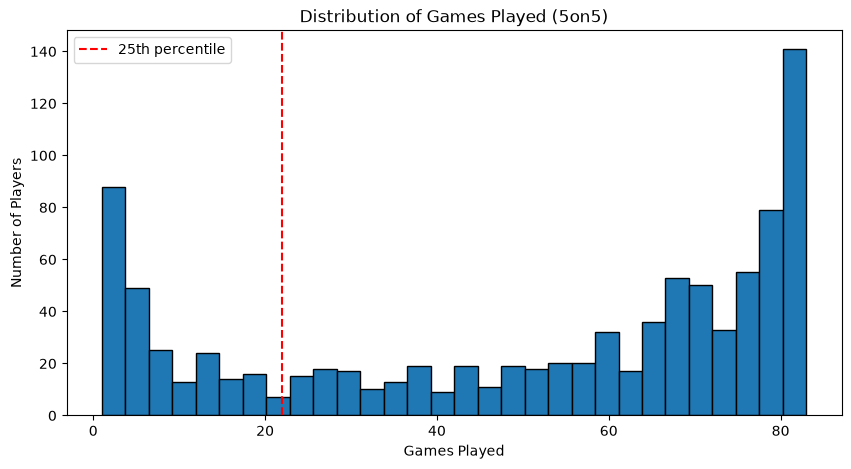

In [10]:
print(final_df['games_played'].describe())
print(f"\nPercentiles:")
print(f"10th: {final_df['games_played'].quantile(0.10):.0f} games")
print(f"25th: {final_df['games_played'].quantile(0.25):.0f} games")
print(f"33rd: {final_df['games_played'].quantile(0.33):.0f} games")

# Distribution
plt.figure(figsize=(10, 5))
plt.hist(final_df['games_played'], bins=30, edgecolor='black')
plt.xlabel('Games Played')
plt.ylabel('Number of Players')
plt.title('Distribution of Games Played (5on5)')
plt.axvline(final_df['games_played'].quantile(0.25), color='red', linestyle='--', label='25th percentile')
plt.legend()
plt.show()

### Hard Cutoff: 20 Games Played

The games-played histogram shows a clear two-population shape: a spike of 
players with only 1-9 games (call-ups, injury replacements, brief roster 
moves), a trough, then a steady climb toward full-season regulars. 20 games 
lands almost exactly on that trough — right where the data naturally 
separates "not a real sample" from "a genuine NHL role" — making it a 
well-justified cutoff rather than an arbitrary round number.

Players after 20-game filter: 715
count    715.0000
mean     880.0264
std      343.6950
min      164.3167
25%      622.4000
50%      906.6000
75%     1123.1167
max     1646.0333
Name: icetime_minutes, dtype: float64

Percentiles:
5th:  295 minutes
10th: 384 minutes
25th: 622 minutes
50th: 907 minutes
75th: 1123 minutes


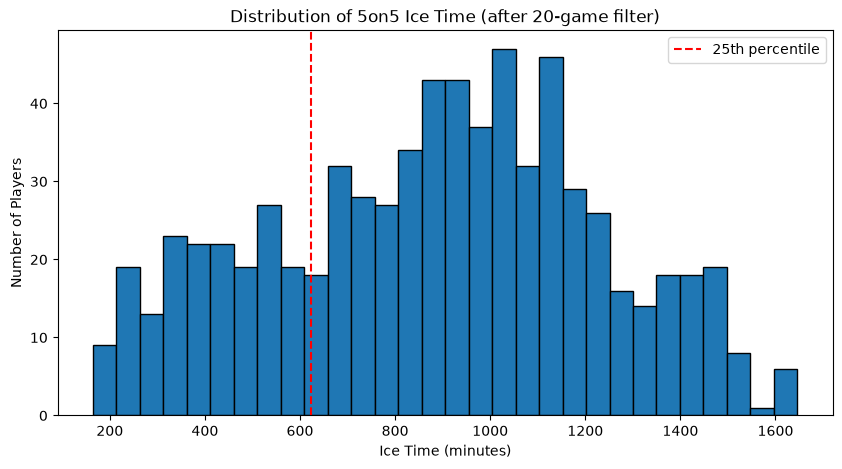

In [11]:
# Apply the 20-game hard filter
final_df = final_df[final_df['games_played'] >= 20].copy()
print(f"Players after 20-game filter: {len(final_df)}")

# Convert icetime to minutes
final_df['icetime_minutes'] = final_df['icetime'] / 60
final_df = final_df.drop(columns=['icetime'])

print(final_df['icetime_minutes'].describe())
print(f"\nPercentiles:")
print(f"5th:  {final_df['icetime_minutes'].quantile(0.05):.0f} minutes")
print(f"10th: {final_df['icetime_minutes'].quantile(0.10):.0f} minutes")
print(f"25th: {final_df['icetime_minutes'].quantile(0.25):.0f} minutes")
print(f"50th: {final_df['icetime_minutes'].quantile(0.50):.0f} minutes")
print(f"75th: {final_df['icetime_minutes'].quantile(0.75):.0f} minutes")

# Distribution
plt.figure(figsize=(10, 5))
plt.hist(final_df['icetime_minutes'], bins=30, edgecolor='black')
plt.xlabel('Ice Time (minutes)')
plt.ylabel('Number of Players')
plt.title('Distribution of 5on5 Ice Time (after 20-game filter)')
plt.axvline(final_df['icetime_minutes'].quantile(0.25), color='red', linestyle='--', label='25th percentile')
plt.legend()
plt.show()

In [12]:
MIN_ICETIME = 200
MAX_ICETIME = final_df['icetime_minutes'].quantile(0.75)

final_df['confidence'] = (0.30 + 0.70 * (
    (final_df['icetime_minutes'] - MIN_ICETIME) / (MAX_ICETIME - MIN_ICETIME)
).clip(0, 1))

print(f"Min icetime threshold: {MIN_ICETIME:.0f} minutes")
print(f"Max icetime threshold: {MAX_ICETIME:.0f} minutes")
print(f"\nConfidence distribution:")
print(final_df['confidence'].describe())


Min icetime threshold: 200 minutes
Max icetime threshold: 1123 minutes

Confidence distribution:
count   715.0000
mean      0.7807
std       0.2145
min       0.3000
25%       0.6203
50%       0.8358
75%       0.9998
max       1.0000
Name: confidence, dtype: float64


### Confidence Weighting: Why 200 Minutes, and What Still Needs Checking

`MAX_ICETIME` (75th percentile, 1,123 minutes) is fully data-driven and 
verified. `MIN_ICETIME = 200` is close to the actual minimum (164), so few 
players hit the literal floor — but the ramp is continuous, not a hard 
cliff, so fringe players (20-28 games) still land at low confidence 
(0.30-0.46) simply from sitting near the bottom of the range, floor or not.

**To verify (once the full composite score is built):** check whether any 
low-ice-time, high-confidence-boosted players are ranking unexpectedly high 
in the final results, and rebuild the composite with an alternate floor 
(e.g. 0.50) to see how much the top of the rankings actually shifts. This 
tells us empirically whether 0.30/0.70 is appropriately balanced, rather 
than assuming it from the formula alone.

## Splitting by Position — Forwards vs. Defensemen

Forwards and defensemen have structurally different roles — defensemen 
are deployed in their own zone far more often, handle the puck under 
different pressure, and naturally post different giveaway rates across 
all three metrics. Comparing a defenseman directly against a forward on 
raw numbers would unfairly penalize defensemen for playing a more 
puck-exposed position.

To account for this, each metric is z-scored (MAD-based, not standard 
deviation — more resistant to the extreme outliers we've already seen 
throughout this data) **separately within each position group**, so a 
player is only measured against others who share a similar defensive 
role, not the league as a whole.

In [13]:
def mad_zscore(series):
    """Modified z-score (Iglewicz & Hoaglin): median instead of mean, MAD 
    instead of std, scaled by 1.4826 (equivalently, ×0.6745 on the raw MAD 
    z-score) so the result lands on the same scale as a standard z-score."""
    median = series.median()
    mad = median_abs_deviation(series, nan_policy='omit', scale='normal')
    return (series - median) / mad
# Separate forwards and defensemen
forwards = final_df[final_df['position'].isin(['C', 'L', 'R'])].copy()
defensemen = final_df[final_df['position'] == 'D'].copy()

print(f"Forwards: {len(forwards)}")
print(f"Defensemen: {len(defensemen)}")

Forwards: 476
Defensemen: 239


In [14]:
EXTREME_RATIO_THRESHOLD = 5  # a player's raw rate is "extreme" if it's 5x+ the position median
LOW_STARTS_THRESHOLD = 15    # combined with a low shift-start count

for df in [forwards, defensemen]:
    med_dzone = df['metric3_dzone_giveaway_rate'].median()
    
    is_extreme_and_unreliable = (
        (df['I_F_dZoneShiftStarts'] < LOW_STARTS_THRESHOLD) &
        (df['metric3_dzone_giveaway_rate'] > EXTREME_RATIO_THRESHOLD * med_dzone)
    )
    
    # For flagged players, override straight to the position median (fully ignore their raw ratio)
    # Everyone else keeps going through the normal confidence-weighting blend
    df.loc[is_extreme_and_unreliable, 'metric3_dzone_giveaway_weighted'] = med_dzone

print("Players caught by this override:")
for df in [forwards, defensemen]:
    flagged = df[
        (df['I_F_dZoneShiftStarts'] < LOW_STARTS_THRESHOLD) &
        (df['metric3_dzone_giveaway_rate'] > EXTREME_RATIO_THRESHOLD * df['metric3_dzone_giveaway_rate'].median())
    ]
    print(flagged[['name','position','I_F_dZoneShiftStarts','metric3_dzone_giveaway_rate']])

Players caught by this override:
              name position  I_F_dZoneShiftStarts  metric3_dzone_giveaway_rate
396  Alex Ovechkin        L                6.0000                       2.3333
Empty DataFrame
Columns: [name, position, I_F_dZoneShiftStarts, metric3_dzone_giveaway_rate]
Index: []


In [15]:
for df in [forwards, defensemen]:
    med_giveaway = df['metric1_giveaway_rate'].median()
    raw_filled_1 = df['metric1_giveaway_rate'].fillna(med_giveaway)
    df['metric1_weighted'] = (df['confidence'] * raw_filled_1) + ((1 - df['confidence']) * med_giveaway)

    med_above_expected = df['metric2_above_expected'].median()
    raw_filled_2 = df['metric2_above_expected'].fillna(med_above_expected)
    df['metric2_weighted'] = (df['confidence'] * raw_filled_2) + ((1 - df['confidence']) * med_above_expected)

In [16]:
forwards[['name', 'metric1_giveaway_rate', 'confidence', 'metric1_weighted', 'metric2_above_expected', 'metric2_weighted']].head(10)

,name,metric1_giveaway_rate,confidence,metric1_weighted,metric2_above_expected,metric2_weighted
0,Sam Lafferty,3.6349,0.3361,3.1566,-0.0012,0.0002
3,Mason Marchment,4.7165,0.9008,4.5377,-0.0001,0.0000
6,Mikael Granlund,2.8538,0.7382,2.8697,0.0064,0.0050
7,Matt Boldy,3.5618,0.9659,3.5397,-0.0023,-0.0022
8,Max Domi,4.5093,0.9353,4.4062,-0.0020,-0.0018
9,Lawson Crouse,2.6192,0.9127,2.6450,-0.0030,-0.0027
10,Andrew Copp,3.8204,0.9343,3.7609,-0.0057,-0.0053
12,Cole Schwindt,1.8539,0.3447,2.5489,0.0150,0.0058
13,Nick Paul,3.0593,0.5945,3.0006,-0.0020,-0.0008
14,Mark Kastelic,2.4044,0.7917,2.5106,0.0037,0.0032


In [17]:
defensemen[['name', 'metric1_giveaway_rate', 'confidence', 'metric1_weighted', 'metric2_above_expected', 'metric2_weighted']].head(10)

,name,metric1_giveaway_rate,confidence,metric1_weighted,metric2_above_expected,metric2_weighted
2,Erik Gudbranson,3.2248,0.5575,3.2351,-0.0024,-0.0010
4,Jacob Bryson,1.9401,0.5470,2.5326,-0.0032,-0.0014
5,Jalen Chatfield,3.0183,1.0000,3.0183,0.0065,0.0065
11,Kyle Capobianco,2.9646,0.4399,3.1233,0.0060,0.0031
22,K'Andre Miller,3.0504,1.0000,3.0504,-0.0003,-0.0003
23,Travis Sanheim,3.5375,1.0000,3.5375,0.0090,0.0090
29,Ilya Lyubushkin,3.4567,0.7143,3.3971,0.0049,0.0037
30,Yan Kuznetsov,3.4627,0.9104,3.4435,-0.0088,-0.0080
32,Trevor van Riemsdyk,2.7850,0.8835,2.8389,0.0019,0.0018
35,Bowen Byram,2.8539,1.0000,2.8539,0.0053,0.0053


In [18]:
# Apply MAD z-scoring within position groups
for df in [forwards, defensemen]:
    df['metric1_z'] = mad_zscore(df['metric1_weighted']) * -1   # lower giveaway rate is better, so flip
    df['metric2_z'] = mad_zscore(df['metric2_weighted'])         # higher above_expected is already better, no flip
    df['metric3_z'] = mad_zscore(df['metric3_dzone_giveaway_weighted']) * -1      # lower dzone rate is better, so flip


In [19]:
forwards.head(5)

,name,team,position,games_played,metric1_giveaway_rate,metric3_dzone_giveaway_rate,metric2_above_expected,total_giveaways,I_F_dZoneShiftStarts,confidence_dzone,metric3_dzone_giveaway_weighted,icetime_minutes,confidence,metric1_weighted,metric2_weighted,metric1_z,metric2_z,metric3_z
0,Sam Lafferty,CHI,C,29,3.6349,0.1667,-0.0012,15.0000,18.0000,0.3000,0.1233,247.6000,0.3361,3.1566,0.0002,-0.4424,-0.1542,-0.3823
3,Mason Marchment,CBJ,L,68,4.7165,0.2151,-0.0001,78.0000,93.0000,0.7189,0.1840,992.2667,0.9008,4.5377,0.0000,-2.9658,-0.2025,-1.7479
6,Mikael Granlund,ANA,C,58,2.8538,0.0863,0.0064,37.0000,139.0000,0.9828,0.0866,777.9000,0.7382,2.8697,0.0050,0.0818,0.8440,0.4418
7,Matt Boldy,MIN,L,76,3.5618,0.1141,-0.0023,64.0000,149.0000,1.0000,0.1141,1078.1167,0.9659,3.5397,-0.0022,-1.1424,-0.6626,-0.1753
8,Max Domi,TOR,C,80,4.5093,0.1361,-0.0020,78.0000,147.0000,1.0000,0.1361,1037.8500,0.9353,4.4062,-0.0018,-2.7256,-0.5837,-0.6691


In [20]:
defensemen.head(5)

,name,team,position,games_played,metric1_giveaway_rate,metric3_dzone_giveaway_rate,metric2_above_expected,total_giveaways,I_F_dZoneShiftStarts,confidence_dzone,metric3_dzone_giveaway_weighted,icetime_minutes,confidence,metric1_weighted,metric2_weighted,metric1_z,metric2_z,metric3_z
2,Erik Gudbranson,CBJ,D,37,3.2248,0.2917,-0.0024,29.0000,72.0000,0.5984,0.2956,539.5667,0.5575,3.2351,-0.0010,0.0254,-0.3048,0.0797
4,Jacob Bryson,WPG,D,50,1.9401,0.1714,-0.0032,17.0000,70.0000,0.5869,0.2252,525.7500,0.5470,2.5326,-0.0014,1.4042,-0.3750,0.9083
5,Jalen Chatfield,CAR,D,72,3.0183,0.2741,0.0065,62.0000,135.0000,0.9598,0.2752,1232.4833,1.0000,3.0183,0.0065,0.4509,0.9623,0.3200
11,Kyle Capobianco,DAL,D,33,2.9646,0.3214,0.0060,19.0000,28.0000,0.3459,0.3084,384.5333,0.4399,3.1233,0.0031,0.2447,0.3857,-0.0706
22,K'Andre Miller,CAR,D,72,3.0504,0.3028,-0.0003,69.0000,142.0000,1.0000,0.3028,1357.2167,1.0000,3.0504,-0.0003,0.3879,-0.1933,-0.0051


In [21]:
player_rankings = pd.concat([forwards, defensemen], ignore_index=True)
print(player_rankings.shape)

player_rankings['composite_score'] = (
    player_rankings['metric1_z'] + player_rankings['metric2_z'] + player_rankings['metric3_z']
)

player_rankings.sort_values('composite_score', ascending=False).head(15)[
    ['name', 'team', 'position', 'metric1_z', 'metric2_z', 'metric3_z', 'composite_score']
]

(715, 18)


,name,team,position,metric1_z,metric2_z,metric3_z,composite_score
167,Luke Glendening,PHI,C,2.0429,1.5475,2.0962,5.6865
691,Jamie Drysdale,PHI,D,2.6770,1.2869,0.8611,4.8251
567,Mikey Anderson,LAK,D,2.2239,0.8021,1.7204,4.7465
565,Alexandre Carrier,MTL,D,1.8678,1.1349,1.5177,4.5204
467,Mathieu Olivier,CBJ,R,1.6155,1.4172,1.2894,4.3222
492,Martin Fehrvry,WSH,D,1.8758,0.6308,1.6866,4.1932
528,Justin Faulk,DET,D,1.4795,1.4549,1.2280,4.1624
264,Justin Hryckowian,DAL,C,2.3182,0.6474,1.1841,4.1497
222,Frederick Gaudreau,SEA,C,0.8603,1.6129,1.6227,4.0959
208,Jack Drury,COL,C,1.0758,1.9217,1.0472,4.0448


In [22]:
player_rankings.sort_values('composite_score').head(10)

,name,team,position,games_played,metric1_giveaway_rate,metric3_dzone_giveaway_rate,metric2_above_expected,total_giveaways,I_F_dZoneShiftStarts,confidence_dzone,metric3_dzone_giveaway_weighted,icetime_minutes,confidence,metric1_weighted,metric2_weighted,metric1_z,metric2_z,metric3_z,composite_score
298,Nathan MacKinnon,COL,C,80,5.7108,0.2833,-0.0018,129.0000,120.0000,0.8738,0.2608,1355.3167,1.0000,5.7108,-0.0018,-5.1093,-0.5877,-3.4737,-9.1707
552,Zayne Parekh,CGY,D,37,6.7747,1.5769,-0.0011,59.0000,26.0000,0.3344,0.7280,522.5333,0.5446,5.1686,-0.0002,-3.7694,-0.1791,-5.0058,-8.9543
307,Evgeni Malkin,PIT,C,56,5.7719,0.5500,-0.0036,74.0000,40.0000,0.4148,0.2894,769.2500,0.7317,5.0051,-0.0024,-3.8198,-0.7057,-4.1171,-8.6426
340,Jack Hughes,NJD,C,61,5.6627,0.4783,0.0029,98.0000,46.0000,0.4492,0.2725,1038.3667,0.9357,5.4861,0.0028,-4.6987,0.3810,-3.7372,-8.0549
157,Martin Necas,COL,C,78,4.3018,0.2906,-0.0075,93.0000,117.0000,0.8566,0.2639,1297.1167,1.0000,4.3018,-0.0075,-2.5349,-1.7993,-3.5445,-7.8787
68,Kirill Marchenko,CBJ,R,76,4.2858,0.3030,-0.0083,82.0000,99.0000,0.7533,0.2541,1147.9833,1.0000,4.2858,-0.0083,-2.5055,-1.9673,-3.3234,-7.7962
435,Macklin Celebrini,SJS,C,82,5.1686,0.2783,0.0004,116.0000,115.0000,0.8451,0.2514,1346.5833,1.0000,5.1686,0.0004,-4.1186,-0.1251,-3.2621,-7.5058
121,Jack Eichel,VGK,C,74,5.1191,0.1810,-0.0059,96.0000,116.0000,0.8508,0.1696,1125.2000,1.0000,5.1191,-0.0059,-4.0281,-1.4554,-1.4245,-6.9080
400,Anthony Mantha,PIT,R,81,4.2864,0.4200,-0.0057,72.0000,50.0000,0.4721,0.2536,1007.8333,0.9126,4.1665,-0.0051,-2.2876,-1.2842,-3.3115,-6.8832
320,Leon Draisaitl,EDM,C,65,4.6731,0.2016,-0.0071,83.0000,124.0000,0.8967,0.1916,1065.6833,0.9564,4.5965,-0.0068,-3.0732,-1.6397,-1.9182,-6.6311


           metric1_z  metric2_z  metric3_z
metric1_z     1.0000     0.0368     0.7019
metric2_z     0.0368     1.0000     0.0301
metric3_z     0.7019     0.0301     1.0000


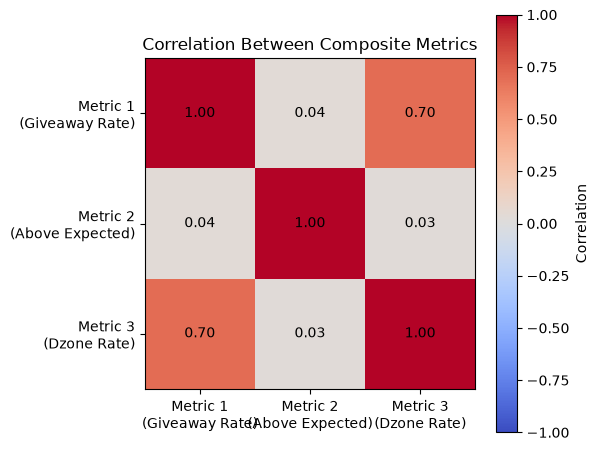

In [24]:
corr_matrix = player_rankings[['metric1_z', 'metric2_z', 'metric3_z']].corr()
print(corr_matrix)

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(3), ['Metric 1\n(Giveaway Rate)', 'Metric 2\n(Above Expected)', 'Metric 3\n(Dzone Rate)'])
plt.yticks(range(3), ['Metric 1\n(Giveaway Rate)', 'Metric 2\n(Above Expected)', 'Metric 3\n(Dzone Rate)'])

# annotate each cell with its actual number
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}', ha='center', va='center', color='black')

plt.title('Correlation Between Composite Metrics')
plt.tight_layout()
plt.show()

### Metric Correlation Check

Metric 1 (giveaway rate) and Metric 3 (dzone giveaway rate) correlate at 
`0.70` — expected, since dzone giveaways are a subset of total giveaways. 
Metric 2 (above expected) is essentially independent of both (`0.03`-`0.04`).

Tested down-weighting Metric 3 to 0.5x to reduce this redundancy — the 
resulting rankings barely changed (9 of the top 10, 9 of the bottom 10 
stayed the same). Given the minimal practical impact, equal weighting 
was kept for simplicity, with this correlation noted as a known, 
explained property of the composite rather than something requiring 
a weighting fix.

In [27]:
# Save final rankings
player_rankings.to_csv('../data/processed/final_rankings.csv', index=False)
print(f"Saved {len(player_rankings)} players to data/processed/final_rankings.csv")

Saved 715 players to data/processed/final_rankings.csv
